## Group 5 | Assignment 1 | Road checker: Assessing Bicycle Lane Quality Using Smartphone Sensor Data

Group members
- Su Acar (2475901)
- Vikram Chandrasekaran (2542544)
- Henrique DaSilva Couto (2463334)


---

# Processing Pipeline at a Glance

The objective of this preprocessing pipeline is to transform raw smartphone
sensor recordings into a compact, physically interpretable feature dataset
for distinguishing **Smooth** and **Bumpy** bicycle paths.

The processing flow is:

```plaintext
RAW SMARTPHONE SENSOR DATA
        │
        ▼
1. DATA INTEGRITY & SAMPLING-RATE VERIFICATION
   ├─ Check required Accelerometer, Gravity and Gyroscope data
   ├─ Estimate actual sampling frequency of every recording
   └─ Exclude participant #03 recordings (~62 Hz)
        │
        │  Reason:
        │  Nyquist ≈ 31 Hz, while relevant frequency features
        │  extend up to 40–46 Hz. Upsampling cannot recover
        │  spectral information that was never measured.
        ▼
2. SENSOR SYNCHRONISATION & CONSOLIDATION
   └─ Merge sensor streams by recording and timestamp
        │
        ▼
3. PHYSICS-BASED SIGNAL DERIVATION
   ├─ Gravity magnitude
   ├─ Vertical dynamic acceleration
   ├─ Gyroscope magnitude
   └─ Vertical jerk
        │
        ▼
4. OPERATIONAL-STATE VERIFICATION
   ├─ 1 s Gyroscope RMS envelope
   ├─ Motion threshold = 0.15 rad/s
   ├─ Detect Stopped / Starting / In Movement / Stopping
   └─ Exclude 2 s transition regions
        │
        │  Only stable "In Movement" data proceeds
        ▼
5. PHYSICS-INFORMED FREQUENCY ANALYSIS
   ├─ Welch PSD on valid riding windows
   ├─ Compare Smooth vs. Bumpy spectral content
   └─ 4–46 Hz Butterworth band-pass used to analyse
      the road-vibration-dominant region
        │
        ▼
6. STATE-GATED WINDOWING & FEATURE EXTRACTION
   ├─ 2 s windows
   ├─ 50% overlap
   └─ Window accepted only when 100% = "In Movement"
        │
        ├─ Time-domain vibration features
        ├─ Gyroscope / jerk features
        └─ Frequency-band power features
        ▼
7. LEAKAGE-SAFE TRAIN / TEST SPLIT
   ├─ Complete recordings kept intact
   ├─ Test set contains both usable participants
   ├─ Test set contains both terrain classes
   └─ Final split ≈ 78% train / 22% test
        │
        ▼
8. TRAINING-ONLY FEATURE REDUNDANCY ANALYSIS
   ├─ Pearson correlation
   ├─ Mutual Information
   └─ Define compact candidate feature sets
        │
        ▼
9. MODEL HAND-OFF
   │
   ├─ compact_physics_5 → recommended starting set
   │  ├─ gyro_rms
   │  ├─ roadband_rms_4_46
   │  ├─ energy_0_3Hz
   │  ├─ energy_10_20Hz
   │  └─ energy_20_40Hz
   │
   ├─ full_12 → reference feature set
   │  ├─ acc_rms
   │  ├─ acc_std
   │  ├─ acc_p2p
   │  ├─ gyro_rms
   │  ├─ jerk_rms
   │  ├─ roadband_rms_4_46
   │  ├─ energy_0_3Hz
   │  ├─ energy_3_10Hz
   │  ├─ energy_10_20Hz
   │  ├─ energy_20_40Hz
   │  ├─ energy_4_46Hz
   │  └─ energy_high_low_ratio
   │
   └─ compact_ratio_4 → minimal alternative
      ├─ gyro_rms
      ├─ roadband_rms_4_46
      ├─ energy_20_40Hz
      └─ energy_high_low_ratio

````

---

# 1) Raw data integrity and sampling-rate checks

## 1.1) Dataset extraction and pre-checks

Downloads the raw sensor data folder from Google Drive into `downloads/` (installing `gdown` if needed). Skip re-running this cell if the data is already present locally.

In [ ]:
#Extract data from Google Drive ONLY IF it is not in the data/ folder yet
# Download gdown-6.2.0

try:
    
    import gdown
    import shutil
except ImportError:
    import subprocess
    import sys

folder_url = "https://drive.google.com/drive/folders/1DpgvoIUkZJ55P85hu4zdvwaJ9wdvKUn8"
output_dir = "downloads/"

gdown.download_folder(
    url=folder_url,
    output=output_dir,
    quiet=False,
    use_cookies=False
)

shutil.move("./downloads/road-checker-data/", "./data/downloads/",)

import os
os.rmdir("./downloads/")

## 1.2) Unzip all recordings and save in the extracted folder

In [1]:
import glob
import zipfile
zip_files = glob.glob("data/downloads/Raw*.zip")

for file_path in zip_files:
    with zipfile.ZipFile(file_path, 'r') as zip_ref:
        folder_name = (zip_ref.filename).split('/')[-1][:-4]
        zip_ref.extractall(f'data/extracted/{folder_name}')

## 1.3) Check Sampling Frequency per sensor across recordings

For each recording, the sampling frequency (Hz) of each sensor is estimated from the mean interval between consecutive `seconds_elapsed` timestamps

The plots below show for each sensor how its sampling frequency varies across recordings (sorted alphabetically by recording name)

This is useful for spotting recordings with inconsistencies and find out which device is causing these

In [2]:
import numpy as np
import pandas as pd
import json

base_path_extracted = "data/extracted"
data_file_mapping = {
    "accelerometer_calibrated" : "Accelerometer.csv",
    # "accelerometer_uncalibrated" : "AccelerometerUncalibrated.csv",
    "gravity" : "Gravity.csv",
    "gyroscope_calibrated": "Gyroscope.csv",
    # "gyroscope_uncalibrated": "GyroscopeUncalibrated.csv"  
}

csv_files = glob.glob("data/extracted/*/*.csv")

recording_sensor_freq_mapping = {}
missing_file_flag = []

for file_path in csv_files: 
    recording_name = file_path.split('/')[-2] + ''
    recording_sensor_freq_mapping[recording_name] = {}
    for sensor, file_name in data_file_mapping.items():
        try:
            sensor_seconds_elapsed_array = pd.read_csv(f"{base_path_extracted }/{recording_name}/{file_name}")['seconds_elapsed']
            dt = sensor_seconds_elapsed_array.diff().mean()
            sensor_sampling_frequency_hz = 1 / dt
            recording_sensor_freq_mapping[recording_name][sensor] = sensor_sampling_frequency_hz
        except FileNotFoundError as e:
            missing_file_flag.append(str(e))
            continue

if len(missing_file_flag):
    print('\n'.join(missing_file_flag))
else:
    print('All recordings are intact with all required sensor data')

print('-------------------------------')
print("Values are in Hz")
print(json.dumps(recording_sensor_freq_mapping, indent = 4, default = str))

All recordings are intact with all required sensor data
-------------------------------
Values are in Hz
{
    "Raw012_Bumpy": {
        "accelerometer_calibrated": 62.20033510900654,
        "gravity": 62.0335142868751,
        "gyroscope_calibrated": 62.152672016968985
    },
    "Raw010_Bumpy": {
        "accelerometer_calibrated": 99.59786331054303,
        "gravity": 99.59786331054303,
        "gyroscope_calibrated": 99.59786331054303
    },
    "Raw030_Bumpy": {
        "accelerometer_calibrated": 62.2394746187573,
        "gravity": 62.14294189348587,
        "gyroscope_calibrated": 62.27560354845678
    },
    "Raw032_Smooth": {
        "accelerometer_calibrated": 99.60750254223494,
        "gravity": 99.60750254223494,
        "gyroscope_calibrated": 99.60750254223494
    },
    "Raw016_Bumpy": {
        "accelerometer_calibrated": 99.59503590582362,
        "gravity": 99.59503590582362,
        "gyroscope_calibrated": 99.59503590582362
    },
    "Raw008_Smooth": {
        "a

## 1.4) Plot the recorded sampling frequencies for selected sensors against raw data package names

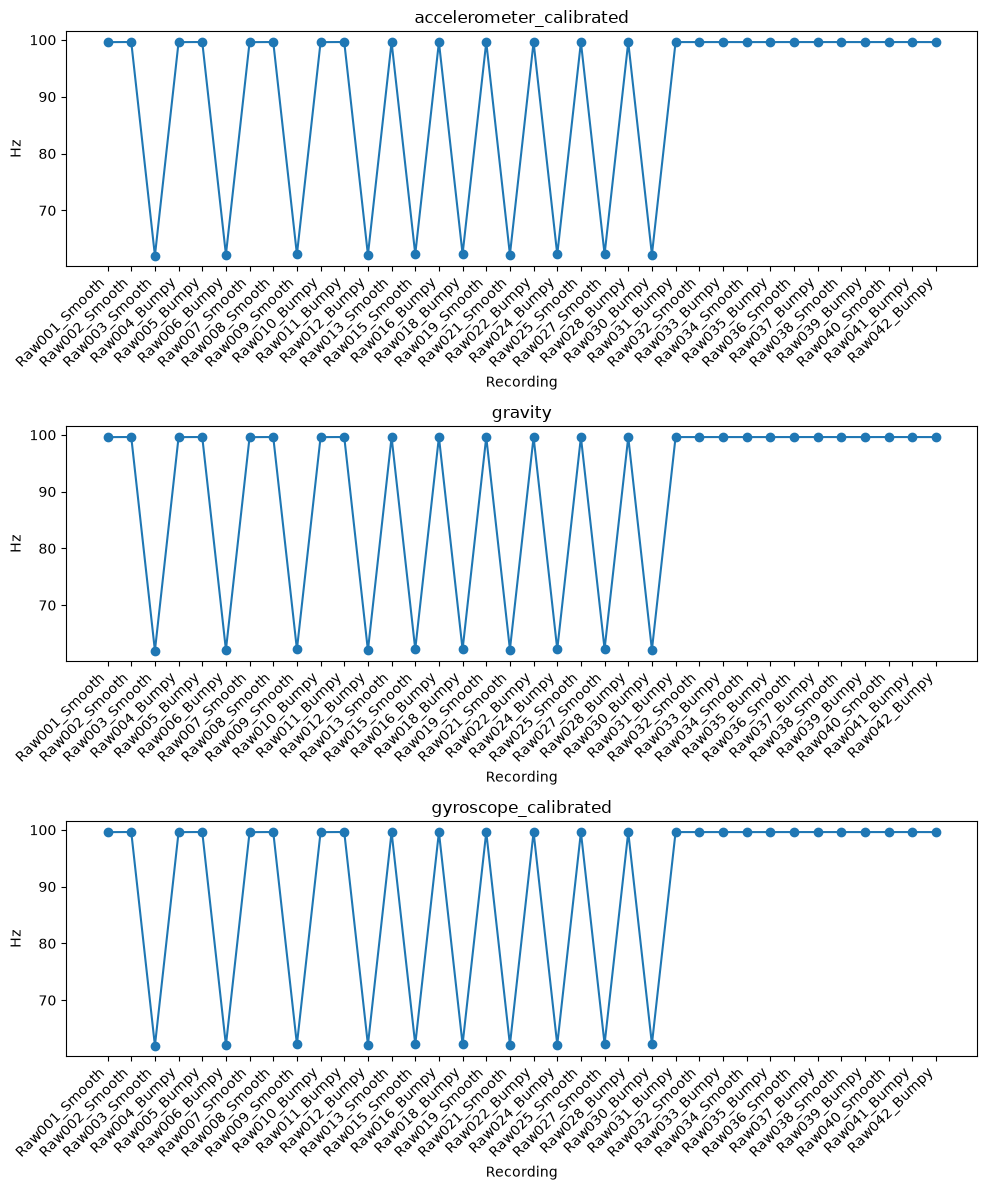

In [3]:
import matplotlib.pyplot as plt

recording_sensor_freq_df = pd.DataFrame(recording_sensor_freq_mapping).T.sort_index()

sensors = recording_sensor_freq_df.columns
fig, axes = plt.subplots(len(sensors), 1, figsize=(10, 4 * len(sensors)))

for ax, sensor in zip(axes, sensors):
    ax.plot(recording_sensor_freq_df.index, recording_sensor_freq_df[sensor], marker='o')
    ax.set_ylabel("Hz")
    ax.set_title(sensor)
    ax.set_xlabel("Recording")
    ax.tick_params(axis='x', rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha('right')

plt.tight_layout()
plt.show()

## 1.5) Filter recordings not having ~100Hz frequency to maintain consistency

In [4]:
delta_threshold = 1  # Hz

filtered_recording_sensor_freq_df = recording_sensor_freq_df[((recording_sensor_freq_df - 100).abs() < delta_threshold).all(axis=1)]

filtered_recording_names = list(filtered_recording_sensor_freq_df.index)


## 1.6) Exclusion criterion applied for data originated from participant #03
Recordings from participant #03 were excluded because the Android acquisition application recorded at approximately 62 Hz despite a configured rate of 100 Hz. This limits the Nyquist frequency to approximately 31 Hz, which is incompatible with the selected frequency-domain features extending to 40–46 Hz. Upsampling would increase the number of samples but could not recover the missing spectral bandwidth; therefore these recordings were excluded to preserve measurement consistency.

# 2) Sensor synchronization

---> Saves all the data in a consolidated csv file

Build one consolidated dataframe with all sensor data for every recording, indexed by `(recording_id, time)` so each row is a single timestamp for one recording.

In [5]:
sensor_data_all_recording_consolidated_df = pd.DataFrame()
axis_list = ['x','y', 'z']

for recording_name in filtered_recording_names:
    # Recording folder names look like "Raw001_Smooth" 
    # split into id and terrain label
    recording_id = recording_name.split('_')[0]
    recording_terrain = recording_name.split('_')[1]

    # Holds this recording's sensors merged side-by-side (columns), built up sensor by sensor
    # aka globally 
    single_recording_consolidated_df = pd.DataFrame()

    for sensor_name, file_name in data_file_mapping.items():
        csv_file = f"data/extracted/{recording_name}/{file_name}"
        temp_df = pd.read_csv(csv_file)

        # Prefix x/y/z with the sensor name so columns stay unique once we merge sensors together
        # e.g. "x" -> "accelerometer_calibrated_x"
        temp_df.rename(columns = {axis: f"{sensor_name}_{axis}" for axis in axis_list}, inplace=True)

        # Index every row with this recording's id, and its timestamp
        recording_ids = [recording_id] * len(temp_df)
        multi_index = pd.MultiIndex.from_arrays([recording_ids, temp_df["time"]],names=["recording_id", "time"],)
        temp_df.set_index(multi_index, inplace=True)

        # We will concatenate at the end once after the merging operations
        seconds_elapsed_column = temp_df['seconds_elapsed']

        # Keep only this sensor's x/y/z axis data
        # This is because seconds_elapsed and time column is redundant in each CSV, and has been indexed in the previous step
        temp_df = temp_df[[f"{sensor_name}_{axis}" for axis in axis_list]]  

        # Add this sensor's columns to the single_recording df, matching rows by the index (recording_id, time)
        single_recording_consolidated_df = pd.concat([single_recording_consolidated_df, temp_df], axis = 1)

    # Add the road terrain label (Bumpy/Smooth) to every row of this single recording
    # Add new column seconds_elapsed from the backup
    single_recording_consolidated_df['recording_terrain'] = [recording_terrain] * len(single_recording_consolidated_df)
    single_recording_consolidated_df['seconds_elapsed'] = seconds_elapsed_column

    # Merge(row-wise) the single_recording df with the globally managed df
    sensor_data_all_recording_consolidated_df = pd.concat([sensor_data_all_recording_consolidated_df, single_recording_consolidated_df])   

sensor_data_all_recording_consolidated_df.to_csv('data/sensor_data_all_recording_consolidated_df.csv')

#Shows one example - from a data-frame search from one of the files

sensor_data_all_recording_consolidated_df.loc[('Raw022')]

,accelerometer_calibrated_x,accelerometer_calibrated_y,accelerometer_calibrated_z,gravity_x,gravity_y,gravity_z,gyroscope_calibrated_x,gyroscope_calibrated_y,gyroscope_calibrated_z,recording_terrain,seconds_elapsed
time,,,,,,,,,,,
1788711711223848700,-0.003646,-0.042070,0.689089,0.616561,3.401584,9.177116,0.571292,0.883160,0.090360,Bumpy,0.059849
1788711711233889800,-0.560752,-0.317377,0.344877,0.550128,3.463508,9.158158,0.786687,0.644196,0.174610,Bumpy,0.069890
1788711711243931000,-0.860728,-0.384643,-0.018512,0.511474,3.541846,9.130394,0.931798,0.356492,0.232991,Bumpy,0.079931
1788711711253971000,-0.871740,-0.229790,-0.164965,0.499741,3.628060,9.097133,0.966161,0.098017,0.255250,Bumpy,0.089971
1788711711264011800,-0.571821,0.026123,-0.234926,0.507776,3.712274,9.062647,0.896838,-0.054720,0.244459,Bumpy,0.100012
...,...,...,...,...,...,...,...,...,...,...,...
1788711782784556000,0.125702,-0.175390,0.187941,0.313933,4.305986,8.805130,0.240119,0.493212,0.173805,Bumpy,71.620556
1788711782794595800,-0.138624,-0.206621,-0.157312,0.285718,4.316119,8.801129,0.001005,0.277910,0.097288,Bumpy,71.630596
1788711782804637000,-0.137713,-0.049010,-0.096526,0.274631,4.305601,8.806632,-0.240557,0.004872,-0.013850,Bumpy,71.640637


# 3) Derived Physical Signals

Based on our physics-informed calibration experiment, we need to isolate the vertical dynamics of the bicycle to separate rider motion (pedaling at ~1-2 Hz) from road surface excitation (higher frequencies depending on speed and terrain gap). 

We will derive the following signals:
* **Gravity magnitude**: Gravity component is already removed from the calibrated accelerometer signal
* **Vertical Dynamic Acceleration**: Projection of the dynamic acceleration onto the gravity unit vector.
* **Gyroscope Magnitude**: Overall rotational energy.
* **Vertical Jerk**: Rate of change of the vertical dynamic acceleration.

In [6]:
from scipy.signal import welch

# 1. Load the consolidated dataset
df = pd.read_csv('data/sensor_data_all_recording_consolidated_df.csv')


# Ensure correct indexing if not automatically parsed
if 'recording_id' in df.columns and 'time' in df.columns:
    df.set_index(['recording_id', 'time'], inplace=True)

# 2. Calculate Gravity Magnitude

df['grav_mag'] = np.sqrt(
        df['gravity_x']**2 +
        df['gravity_y']**2 +
        df['gravity_z']**2
)

df['vertical_dyn_acc'] = (
    df['accelerometer_calibrated_x'] * (df['gravity_x'] / df['grav_mag']) +
    df['accelerometer_calibrated_y'] * (df['gravity_y'] / df['grav_mag']) +
    df['accelerometer_calibrated_z'] * (df['gravity_z'] / df['grav_mag'])
)

# 5. Calculate Gyroscope Magnitude
df['gyro_mag'] = np.sqrt(df['gyroscope_calibrated_x']**2 + 
                         df['gyroscope_calibrated_y']**2 + 
                         df['gyroscope_calibrated_z']**2)

# 6. Calculate Vertical Jerk
# Assuming ~100Hz sampling rate, dt = 0.01 seconds
df['jerk_vertical'] = (
    df.groupby(level='recording_id')['vertical_dyn_acc'].diff() / 0.01
)

df['jerk_vertical'] = df['jerk_vertical'].fillna(0)

print("Derived features calculated successfully.")
print(df.isna().sum()[df.isna().sum() > 0])

Derived features calculated successfully.
Series([], dtype: int64)


# 4) Operational State Verification (DSP Time-Domain Approach)

Before windowing our data for the terrain classifier, we must ensure we only feed it data where the bicycle is in a valid **"In Movement"** state. If we include data where the rider is stopped, starting to pedal, or braking, the terrain classifier will learn invalid noise.

To do this sequentially in the time domain, we apply a classic DSP envelope detection strategy:
1. **Envelope Calculation:** We calculate a 1-second rolling Root Mean Square (RMS) of the Gyroscope Magnitude. This acts as a low-pass filter, giving us the continuous rotational energy.
2. **Thresholding:** The 0.15 rad/s threshold was initially selected by inspection of the gyroscope RMS envelope and subsequently evaluated through a sensitivity analysis. Only a small proportion of samples lies close to the selected decision boundary, indicating limited sensitivity to modest threshold changes.
3. **Transient Buffering (State Machine):** The moments immediately after crossing the threshold are flagged as "Starting" (2-second buffer), and the moments right before stopping are flagged as "Stopping". 

Only the steady-state data flagged strictly as **"In Movement"** will be passed to our windowing function.

In [7]:
from matplotlib.patches import Patch

# ------------------------------------------------------------
# Operational State Verification
# ------------------------------------------------------------

fs = 100.0
envelope_window = int(1.0 * fs)     # 1 s RMS envelope
transition_buffer = int(2.0 * fs)   # 2 s transient exclusion
motion_threshold = 0.15             # rad/s

# These columns are now created ONCE and reused later
df['gyro_rms_envelope'] = np.nan
df['operational_state'] = 'Stopped'


def iter_recordings(frame):
    """Works whether recording_id is an index level or a normal column."""
    if (
        isinstance(frame.index, pd.MultiIndex)
        and 'recording_id' in frame.index.names
    ):
        return frame.groupby(level='recording_id', sort=False)

    return frame.groupby('recording_id', sort=False)


for recording_id, group in iter_recordings(df):

    # 1-second RMS envelope of gyroscope magnitude
    gyro_rms_env = (
        group['gyro_mag']
        .rolling(
            window=envelope_window,
            center=True,
            min_periods=envelope_window
        )
        .apply(lambda x: np.sqrt(np.mean(x**2)))
    )

    is_active = gyro_rms_env > motion_threshold

    # Detect transitions
    state_change = is_active.astype(int).diff()
    starts = state_change == 1
    stops = state_change == -1

    # Exclude 2 seconds immediately after starting
    starting_mask = (
        starts
        .rolling(window=transition_buffer, min_periods=1)
        .max()
        .astype(bool)
    )

    # Exclude 2 seconds immediately before stopping
    stopping_mask = (
        stops.iloc[::-1]
        .rolling(window=transition_buffer, min_periods=1)
        .max()
        .iloc[::-1]
        .astype(bool)
    )

    state_array = np.full(len(group), 'Stopped', dtype=object)

    state_array[is_active.fillna(False).to_numpy()] = 'In Movement'

    state_array[
        (
            is_active.fillna(False)
            & starting_mask
        ).to_numpy()
    ] = 'Starting'

    state_array[
        (
            is_active.fillna(False)
            & stopping_mask
        ).to_numpy()
    ] = 'Stopping'

    df.loc[group.index, 'gyro_rms_envelope'] = gyro_rms_env.to_numpy()
    df.loc[group.index, 'operational_state'] = state_array

## 4.1) Threshold Empirical investigation

,threshold_rad_s,samples_above_threshold_pct
0,0.10,97.93
1,0.12,97.77
2,0.15,97.41
3,0.18,96.67
4,0.20,95.73
5,0.22,94.74
6,0.25,93.54
7,0.27,92.50
8,0.30,91.52


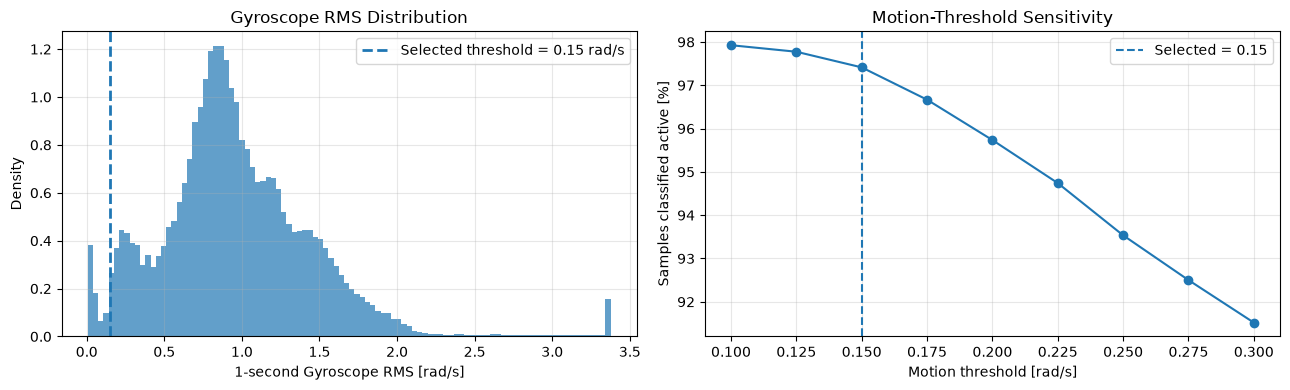

Samples within ±20% of selected threshold: 1.35%


In [8]:
# ------------------------------------------------------------
# Empirical sensitivity analysis of the motion threshold
# ------------------------------------------------------------

envelope_values = df['gyro_rms_envelope'].dropna()

threshold_candidates = np.arange(
    0.10,
    0.31,
    0.025
)

sensitivity = []

for threshold in threshold_candidates:

    active_fraction = (
        envelope_values > threshold
    ).mean() * 100

    sensitivity.append({
        'threshold_rad_s': threshold,
        'samples_above_threshold_pct': active_fraction
    })

sensitivity_df = pd.DataFrame(sensitivity)

display(sensitivity_df.round(2))


fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4)
)

# Distribution
plot_limit = envelope_values.quantile(0.995)

axes[0].hist(
    envelope_values.clip(upper=plot_limit),
    bins=100,
    density=True,
    alpha=0.7
)

axes[0].axvline(
    motion_threshold,
    linestyle='--',
    linewidth=2,
    label=f'Selected threshold = {motion_threshold:.2f} rad/s'
)

axes[0].set_xlabel('1-second Gyroscope RMS [rad/s]')
axes[0].set_ylabel('Density')
axes[0].set_title('Gyroscope RMS Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)


# Threshold sensitivity
axes[1].plot(
    sensitivity_df['threshold_rad_s'],
    sensitivity_df['samples_above_threshold_pct'],
    marker='o'
)

axes[1].axvline(
    motion_threshold,
    linestyle='--',
    label=f'Selected = {motion_threshold:.2f}'
)

axes[1].set_xlabel('Motion threshold [rad/s]')
axes[1].set_ylabel('Samples classified active [%]')
axes[1].set_title('Motion-Threshold Sensitivity')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


near_threshold = (
    (envelope_values >= 0.8 * motion_threshold)
    & (envelope_values <= 1.2 * motion_threshold)
).mean() * 100

print(
    f"Samples within ±20% of selected threshold: "
    f"{near_threshold:.2f}%"
)

## 4.2) Operational state visualisation


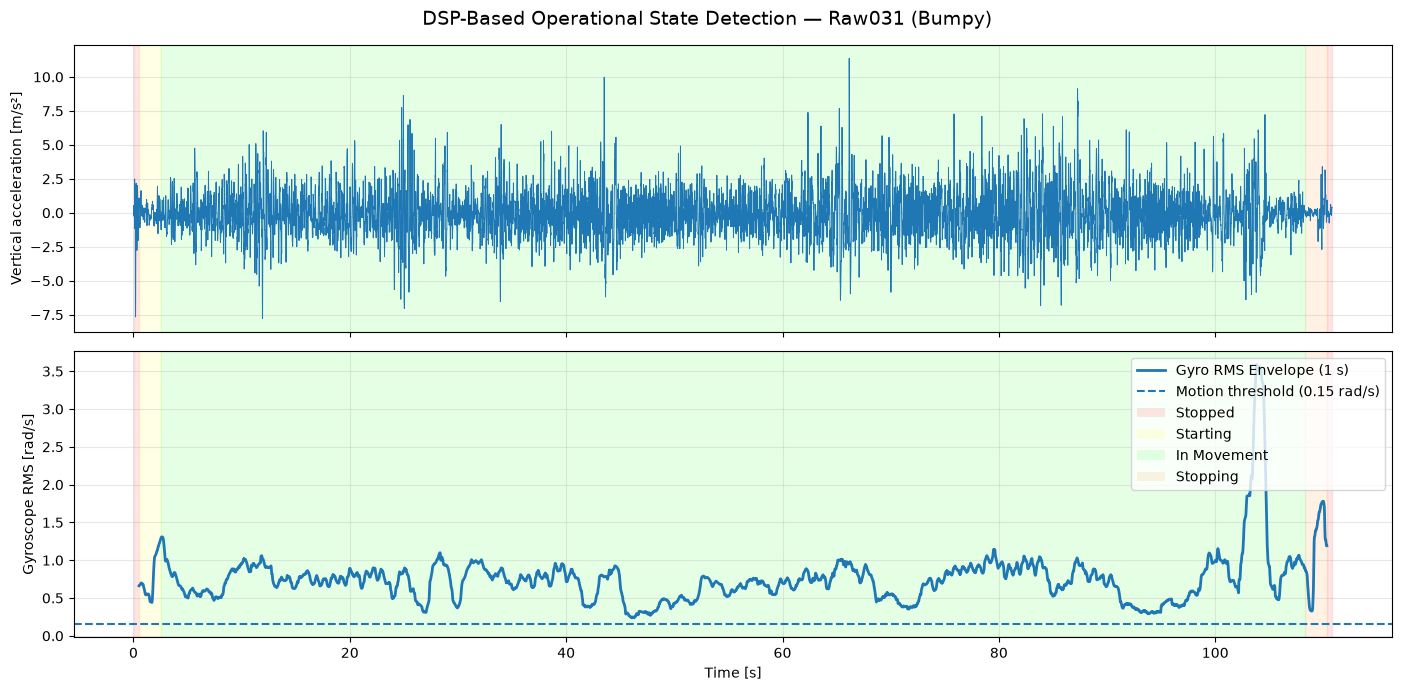

In [11]:
# ------------------------------------------------------------
# Representative operational-state visualisation
# ------------------------------------------------------------

plot_sample = "Raw031"

if (
    isinstance(df.index, pd.MultiIndex)
    and 'recording_id' in df.index.names
):
    sample_rec = df.xs(
        plot_sample,
        level='recording_id'
    ).copy()
else:
    sample_rec = df[
        df['recording_id'] == plot_sample
    ].copy()

terrain_label = sample_rec['recording_terrain'].iloc[0]
time = sample_rec['seconds_elapsed']

state_colors = {
    'Stopped': '#ff9999',
    'Starting': '#ffff99',
    'In Movement': '#99ff99',
    'Stopping': '#ffcc99'
}

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 7),
    sharex=True
)

# ---- Raw vertical acceleration
axes[0].plot(
    time,
    sample_rec['vertical_dyn_acc'],
    linewidth=0.7
)

axes[0].set_ylabel('Vertical acceleration [m/s²]')
axes[0].grid(alpha=0.3)

# ---- Gyroscope RMS envelope
axes[1].plot(
    time,
    sample_rec['gyro_rms_envelope'],
    linewidth=2,
    label='Gyro RMS Envelope (1 s)'
)

axes[1].axhline(
    motion_threshold,
    linestyle='--',
    label=f'Motion threshold ({motion_threshold:.2f} rad/s)'
)

axes[1].set_ylabel('Gyroscope RMS [rad/s]')
axes[1].set_xlabel('Time [s]')
axes[1].grid(alpha=0.3)

# Shade operational states in both panels
for state, color in state_colors.items():

    mask = sample_rec['operational_state'] == state

    for ax in axes:
        ax.fill_between(
            time,
            0,
            1,
            where=mask,
            transform=ax.get_xaxis_transform(),
            color=color,
            alpha=0.25
        )

state_legend = [
    Patch(
        facecolor=color,
        alpha=0.25,
        label=state
    )
    for state, color in state_colors.items()
]

handles, labels = axes[1].get_legend_handles_labels()

axes[1].legend(
    handles + state_legend,
    labels + list(state_colors.keys()),
    loc='upper right'
)

fig.suptitle(
    f'DSP-Based Operational State Detection — '
    f'{plot_sample} ({terrain_label})',
    fontsize=14
)

plt.tight_layout()
plt.show()

# 5) Physics-Informed Frequency Analysis

## 5.1) Exploratory Data Analysis: Frequency Domain Verification (PSD)

Before engineering features for our machine learning models, we must verify our physical hypothesis: *Does the bumpy terrain actually exhibit higher energy in the expected frequency bands compared to smooth terrain?* 

Based on our calibration experiment, we expect rider motion (pedaling) to dominate the low frequencies (~1-3 Hz), while road surface excitations will appear in the higher frequencies depending on speed and terrain gaps (~5-45Hz)

We will use Welch's method to estimate the Power Spectral Density (PSD) and confirm these separation boundaries.

## 5.2) Initial frequency analysis

In [12]:
from scipy.signal import butter, sosfiltfilt, welch

# ------------------------------------------------------------
# State-Gated Physics-Informed Frequency Analysis
# ------------------------------------------------------------

fs = 100.0

window_size = 200       # 2 s
step_size = 100         # 50% overlap

lowcut = 4.0
highcut = 46.0
filter_order = 4

nyquist = fs / 2

if highcut >= nyquist:
    raise ValueError(
        f"High cutoff ({highcut} Hz) must be below "
        f"Nyquist ({nyquist} Hz)."
    )

# Design Butterworth bandpass
roadband_sos = butter(
    filter_order,
    [lowcut, highcut],
    btype='bandpass',
    fs=fs,
    output='sos'
)

print("Butterworth filter created successfully.")
print("SOS shape:", roadband_sos.shape)

df['roadband_acc_4_46'] = np.nan

for recording_id, group in iter_recordings(df):

    group = group.sort_values('seconds_elapsed')

    signal = group['vertical_dyn_acc'].to_numpy(dtype=float)

    if not np.isfinite(signal).all():
        raise ValueError(
            f"{recording_id}: vertical_dyn_acc contains "
            "NaN or infinite values."
        )

    filtered_signal = sosfiltfilt(
        roadband_sos,
        signal
    )

    df.loc[
        group.index,
        'roadband_acc_4_46'
    ] = filtered_signal

print("4–46 Hz filtering completed for all recordings.")

Butterworth filter created successfully.
SOS shape: (4, 6)
4–46 Hz filtering completed for all recordings.


## 5.3) Collect valid windows (only classified as 'in motion' from section 4)

In [13]:
# ------------------------------------------------------------
# Collect valid windows and PSDs
# ------------------------------------------------------------

psd_by_terrain = {
    'Smooth': [],
    'Bumpy': []
}

valid_windows = []

df_grouped = df.reset_index()

for recording_id, group in df_grouped.groupby(
    'recording_id',
    sort=False
):

    group = group.sort_values('seconds_elapsed')

    terrain = group['recording_terrain'].iloc[0]

    raw_acc = group['vertical_dyn_acc'].to_numpy()
    filtered_acc = group['roadband_acc_4_46'].to_numpy()
    states = group['operational_state'].to_numpy()
    time = group['seconds_elapsed'].to_numpy()

    n_windows = (
        (len(group) - window_size)
        // step_size
        + 1
    )

    for i in range(n_windows):

        start = i * step_size
        end = start + window_size

        # Same strict gating used later for ML
        if not np.all(
            states[start:end] == 'In Movement'
        ):
            continue

        raw_window = raw_acc[start:end]
        filtered_window = filtered_acc[start:end]
        time_window = time[start:end]

        freqs, psd = welch(
            raw_window,
            fs=fs,
            nperseg=window_size,
            detrend='constant'
        )

        psd_by_terrain[terrain].append(psd)

        valid_windows.append({
            'recording_id': recording_id,
            'terrain': terrain,
            'time': time_window,
            'raw': raw_window,
            'filtered': filtered_window,
            'roadband_rms': np.sqrt(
                np.mean(filtered_window**2)
            )
        })


print(
    "Valid In-Movement windows:"
)

for terrain in ['Smooth', 'Bumpy']:
    print(
        f"  {terrain}: "
        f"{len(psd_by_terrain[terrain])}"
    )

Valid In-Movement windows:
  Smooth: 2431
  Bumpy: 1815


## 5.4) Quantitative summary

In [14]:
window_summary_df = pd.DataFrame([
    {
        'recording_id': w['recording_id'],
        'terrain': w['terrain'],
        'roadband_rms': w['roadband_rms']
    }
    for w in valid_windows
])

roadband_summary = (
    window_summary_df
    .groupby('terrain')['roadband_rms']
    .agg([
        'count',
        'mean',
        'median',
        'std'
    ])
)

display(roadband_summary.round(3))

median_smooth = roadband_summary.loc[
    'Smooth', 'median'
]

median_bumpy = roadband_summary.loc[
    'Bumpy', 'median'
]

print(
    "Median Bumpy / Smooth road-band RMS ratio: "
    f"{median_bumpy / median_smooth:.2f}x"
)

,count,mean,median,std
terrain,,,,
Bumpy,1815,1.355,1.205,0.654
Smooth,2431,0.746,0.673,0.311


Median Bumpy / Smooth road-band RMS ratio: 1.79x


## 5.5) Visual representation (PSD plot)

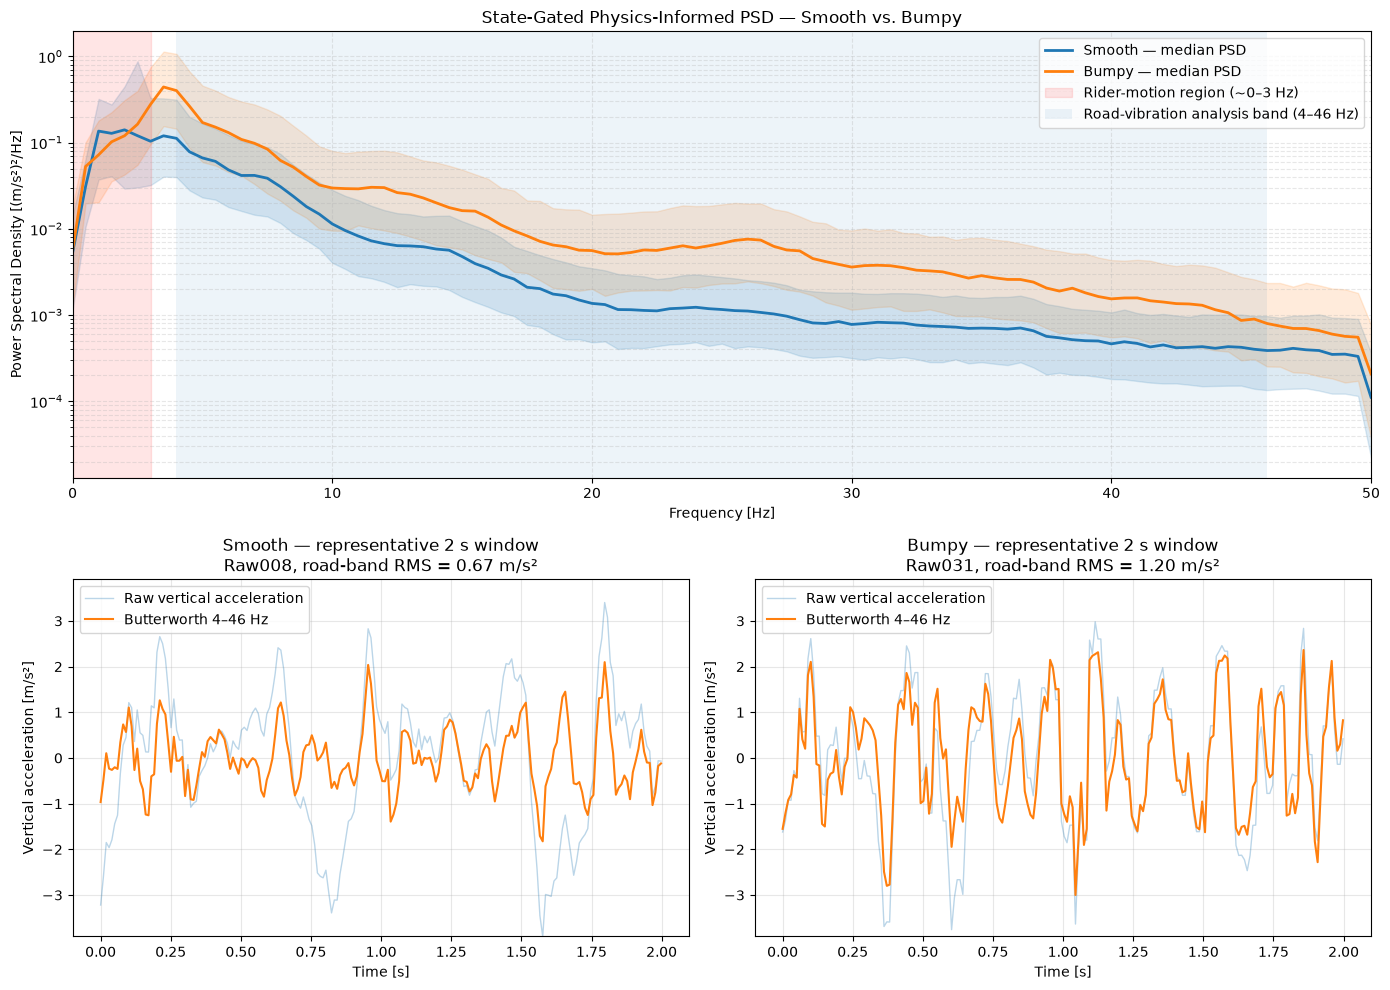

In [15]:
# ------------------------------------------------------------
# Aggregate PSD by terrain
# ------------------------------------------------------------

psd_summary = {}

for terrain in ['Smooth', 'Bumpy']:

    stack = np.vstack(
        psd_by_terrain[terrain]
    )

    psd_summary[terrain] = {
        'median': np.median(stack, axis=0),
        'q25': np.percentile(stack, 25, axis=0),
        'q75': np.percentile(stack, 75, axis=0)
    }


# ------------------------------------------------------------
# Choose objectively representative time-domain windows
# ------------------------------------------------------------

representative = {}

for terrain in ['Smooth', 'Bumpy']:

    candidates = [
        window
        for window in valid_windows
        if window['terrain'] == terrain
    ]

    class_median_rms = np.median([
        w['roadband_rms']
        for w in candidates
    ])

    representative[terrain] = min(
        candidates,
        key=lambda w:
            abs(
                w['roadband_rms']
                - class_median_rms
            )
    )


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig = plt.figure(figsize=(14, 10))

gs = fig.add_gridspec(
    2,
    2,
    height_ratios=[1.25, 1]
)

ax_psd = fig.add_subplot(gs[0, :])
ax_smooth = fig.add_subplot(gs[1, 0])
ax_bumpy = fig.add_subplot(gs[1, 1])


# ---- PSD
for terrain in ['Smooth', 'Bumpy']:

    summary = psd_summary[terrain]

    line, = ax_psd.semilogy(
        freqs,
        summary['median'],
        linewidth=2,
        label=f'{terrain} — median PSD'
    )

    ax_psd.fill_between(
        freqs,
        summary['q25'],
        summary['q75'],
        alpha=0.15,
        color=line.get_color()
    )


# Physics-informed regions
ax_psd.axvspan(
    0,
    3,
    alpha=0.10,
    color='red',
    label='Rider-motion region (~0–3 Hz)'
    
)

ax_psd.axvspan(
    lowcut,
    highcut,
    alpha=0.08,
    label='Road-vibration analysis band (4–46 Hz)'
)

ax_psd.set_xlim(0, 50)

ax_psd.set_xlabel('Frequency [Hz]')
ax_psd.set_ylabel(
    'Power Spectral Density [(m/s²)²/Hz]'
)

ax_psd.set_title(
    'State-Gated Physics-Informed PSD — '
    'Smooth vs. Bumpy'
)

ax_psd.grid(
    True,
    which='both',
    linestyle='--',
    alpha=0.3
)

ax_psd.legend()


# ---- Representative time-domain windows
for ax, terrain in [
    (ax_smooth, 'Smooth'),
    (ax_bumpy, 'Bumpy')
]:

    window = representative[terrain]

    t = (
        window['time']
        - window['time'][0]
    )

    ax.plot(
        t,
        window['raw'],
        alpha=0.30,
        linewidth=1,
        label='Raw vertical acceleration'
    )

    ax.plot(
        t,
        window['filtered'],
        linewidth=1.5,
        label='Butterworth 4–46 Hz'
    )

    ax.set_title(
        f"{terrain} — representative 2 s window\n"
        f"{window['recording_id']}, "
        f"road-band RMS = "
        f"{window['roadband_rms']:.2f} m/s²"
    )

    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Vertical acceleration [m/s²]')
    ax.grid(alpha=0.3)
    ax.legend()


# Same vertical scale for honest visual comparison
comparison_limit = max(
    np.max(
        np.abs(
            representative['Smooth']['raw']
        )
    ),
    np.max(
        np.abs(
            representative['Bumpy']['raw']
        )
    ),
    np.max(
        np.abs(
            representative['Smooth']['filtered']
        )
    ),
    np.max(
        np.abs(
            representative['Bumpy']['filtered']
        )
    )
)

ax_smooth.set_ylim(
    -comparison_limit,
    comparison_limit
)

ax_bumpy.set_ylim(
    -comparison_limit,
    comparison_limit
)

plt.tight_layout()
plt.show()

# 6) Windowing + Feature Extraction
## 6.1) Data Preparation: State-Gated Windowing and Feature Extraction

Machine learning algorithms require discrete, tabular data rather than continuous time-series waves. To achieve this, we segment our continuous recordings into **2-second sliding windows with a 50% overlap**. 

**Crucial Step: Operational Gating**
Before extracting features, we apply a strict filter: a window is only retained if **100% of its samples** are classified as "In Movement" by our DSP state machine. This guarantees our machine learning model only trains on steady-state riding vibrations, completely ignoring the mechanical noise of starting, stopping, or standing still.

For each valid "In Movement" window, we extract features that capture the physical dynamics of the ride:
1. **Time-Domain Features**: RMS, Standard Deviation, and Peak-to-Peak (capturing overall vibration amplitude).
2. **Rotational & Derivative Features**: Gyroscope RMS and Jerk RMS (capturing sudden jolts and bike stability).
3. **Frequency-Domain Features**: Energy grouped into the specific physical bands established in our PSD analysis (0-3 Hz, 3-10 Hz, 10-20 Hz, 20-40 Hz), as well as a High/Low energy ratio to explicitly contrast road noise against rider motion.

In [16]:
import numpy as np
import pandas as pd
from scipy.signal import welch


# ------------------------------------------------------------
# State-Gated Windowing & Feature Extraction
# ------------------------------------------------------------

fs = 100.0

window_size = 200   # 2 seconds
step_size = 100     # 50% overlap


def bandpower(freqs, psd, low, high):
    """
    Integrate the PSD over a frequency band.
    """
    mask = (
        (freqs >= low)
        & (freqs < high)
    )

    return np.trapezoid(
        psd[mask],
        freqs[mask]
    )


features_list = []

# recording_id becomes a normal column
df_grouped = df.reset_index()


for recording_id, group in df_grouped.groupby(
    'recording_id',
    sort=False
):

    # Important: preserve chronological order
    group = (
        group
        .sort_values('seconds_elapsed')
        .reset_index(drop=True)
    )

    terrain_label = group[
        'recording_terrain'
    ].iloc[0]

    vert_acc = group[
        'vertical_dyn_acc'
    ].to_numpy()

    roadband_acc = group[
        'roadband_acc_4_46'
    ].to_numpy()

    gyro_mag = group[
        'gyro_mag'
    ].to_numpy()

    jerk = group[
        'jerk_vertical'
    ].to_numpy()

    states = group[
        'operational_state'
    ].to_numpy()


    n_windows = (
        (len(group) - window_size)
        // step_size
        + 1
    )


    for i in range(n_windows):

        start = i * step_size
        end = start + window_size

        window_states = states[start:end]

        # ----------------------------------------------------
        # Operational-state gating
        # ----------------------------------------------------
        # Keep the window only if ALL 2 seconds correspond
        # to stable riding.
        if not np.all(
            window_states == 'In Movement'
        ):
            continue


        window_acc = vert_acc[start:end]
        window_roadband = roadband_acc[start:end]
        window_gyro = gyro_mag[start:end]
        window_jerk = jerk[start:end]


        # Defensive check
        if not (
            np.isfinite(window_acc).all()
            and np.isfinite(window_roadband).all()
            and np.isfinite(window_gyro).all()
            and np.isfinite(window_jerk).all()
        ):
            continue


        # ----------------------------------------------------
        # Frequency-domain analysis
        # ----------------------------------------------------

        freqs, psd = welch(
            window_acc,
            fs=fs,
            nperseg=window_size,
            detrend='constant'
        )


        band_0_3 = bandpower(
            freqs, psd, 0, 3
        )

        band_3_10 = bandpower(
            freqs, psd, 3, 10
        )

        band_10_20 = bandpower(
            freqs, psd, 10, 20
        )

        band_20_40 = bandpower(
            freqs, psd, 20, 40
        )

        band_4_46 = bandpower(
            freqs, psd, 4, 46
        )


        # ----------------------------------------------------
        # Time-domain / physics-informed features
        # ----------------------------------------------------

        roadband_rms = np.sqrt(
            np.mean(window_roadband**2)
        )


        features = {

            # Metadata
            'recording_id': recording_id,
            'terrain': terrain_label,

            'window_index': i,
            'window_start_s': group['seconds_elapsed'].iloc[start],
            'window_end_s': group['seconds_elapsed'].iloc[end - 1],

            # Raw vertical-acceleration features
            'acc_rms': np.sqrt(
                np.mean(window_acc**2)
            ),

            'acc_std': np.std(
                window_acc
            ),

            'acc_p2p': (
                np.max(window_acc)
                - np.min(window_acc)
            ),

            # Other physical signals
            'gyro_rms': np.sqrt(
                np.mean(window_gyro**2)
            ),

            'jerk_rms': np.sqrt(
                np.mean(window_jerk**2)
            ),

            # Physics-informed filtered vibration feature
            'roadband_rms_4_46': roadband_rms,

            # Integrated PSD band powers
            'energy_0_3Hz': band_0_3,
            'energy_3_10Hz': band_3_10,
            'energy_10_20Hz': band_10_20,
            'energy_20_40Hz': band_20_40,
            'energy_4_46Hz': band_4_46,

            # Relative high-frequency road-vibration content
            'energy_high_low_ratio': (
                band_10_20 + band_20_40
            ) / (
                band_0_3 + 1e-6
            )
        }

        features_list.append(
            features
        )


features_df = pd.DataFrame(
    features_list
)

print(
    f"Extracted {len(features_df)} "
    "'In-Movement' windows."
)

Extracted 4246 'In-Movement' windows.


## 6.2) Display features

In [17]:
display(
    features_df.groupby('terrain')[
        [
            'acc_rms',
            'roadband_rms_4_46',
            'energy_4_46Hz',
            'energy_high_low_ratio'
        ]
    ].agg([
        'count',
        'mean',
        'median',
        'std'
    ]).round(3)
)

acc_rms                      roadband_rms_4_46                       \
          count   mean median    std             count   mean median    std   
terrain                                                                       
Bumpy      1815  1.904  1.706  0.860              1815  1.355  1.205  0.654   
Smooth     2431  1.232  1.116  0.538              2431  0.746  0.673  0.311   

        energy_4_46Hz                      energy_high_low_ratio         \
                count   mean median    std                 count   mean   
terrain                                                                   
Bumpy            1815  2.603  1.548  3.709                  1815  3.891   
Smooth           2431  0.769  0.490  1.069                  2431  1.724   

                       
        median    std  
terrain                
Bumpy    1.811  7.741  
Smooth   0.327  6.417

# 7) Group-aware Train/Test Split

## 7.1) Create model data structure

In [18]:
# ------------------------------------------------------------
# Model Features & Target
# ------------------------------------------------------------

all_feature_cols = [
    'acc_rms',
    'acc_std',
    'acc_p2p',
    'gyro_rms',
    'jerk_rms',
    'roadband_rms_4_46',
    'energy_0_3Hz',
    'energy_3_10Hz',
    'energy_10_20Hz',
    'energy_20_40Hz',
    'energy_4_46Hz',
    'energy_high_low_ratio'
]

X_all = features_df[all_feature_cols].copy()

y = features_df['terrain'].map({
    'Smooth': 0,
    'Bumpy': 1
})

assert y.notna().all()

## 7.2) Address the data files that came from the same recording which was split from annotations file

In [19]:


# Raw031–Raw037 came from the same original recording
# Raw038–Raw041 came from another original recording

parent_session_map = {}

for n in range(31, 38):
    parent_session_map[
        f'Raw{n:03d}'
    ] = 'AnnotatedSession01'

for n in range(38, 42):
    parent_session_map[
        f'Raw{n:03d}'
    ] = 'AnnotatedSession02'


features_df[
    'split_group'
] = (
    features_df[
        'recording_id'
    ]
    .map(parent_session_map)
    .fillna(
        features_df[
            'recording_id'
        ]
    )
)

groups = features_df[
    'split_group'
]



## 7.3) Separate train / test data according to the multi-participant isolation in different conditions

The hold-out set was constructed at recording level, retaining complete independent recordings and including both available participants and both terrain classes. 

The resulting split contained approximately 22% of the valid windows for testing.

In [20]:
# ------------------------------------------------------------
# Deterministic Multi-Participant Holdout
# ------------------------------------------------------------

test_recordings = [
    # Participant #01
    'Raw001',   # Smooth
    'Raw022',   # Bumpy

    # Participant #02
    'Raw008',   # Smooth
    'Raw011'    # Bumpy
]


test_mask = (
    features_df['recording_id']
    .isin(test_recordings)
)

train_mask = ~test_mask


train_idx = np.flatnonzero(
    train_mask.to_numpy()
)

test_idx = np.flatnonzero(
    test_mask.to_numpy()
)


X_train_full = features_df.loc[
    train_mask,
    all_feature_cols
].copy()

X_test_full = features_df.loc[
    test_mask,
    all_feature_cols
].copy()


y_train = y.loc[
    train_mask
].copy()

y_test = y.loc[
    test_mask
].copy()


groups_train = features_df.loc[
    train_mask,
    'split_group'
].copy()

groups_test = features_df.loc[
    test_mask,
    'split_group'
].copy()


print("--- Deterministic Multi-Participant Holdout ---")

print(
    f"Training windows: {len(X_train_full)} "
    f"({len(X_train_full)/len(features_df):.1%})"
)

print(
    f"Testing windows:  {len(X_test_full)} "
    f"({len(X_test_full)/len(features_df):.1%})"
)

print("\nHeld-out recordings:")

for recording in test_recordings:
    print(f"  - {recording}")

--- Deterministic Multi-Participant Holdout ---
Training windows: 3311 (78.0%)
Testing windows:  935 (22.0%)

Held-out recordings:
  - Raw001
  - Raw022
  - Raw008
  - Raw011


## 7.4) Check for leakages

In [21]:
# ------------------------------------------------------------
# Split Integrity Checks
# ------------------------------------------------------------

train_groups = set(
    groups_train.unique()
)

test_groups = set(
    groups_test.unique()
)


# No parent recording may exist on both sides
assert train_groups.isdisjoint(
    test_groups
)

# Both classes must exist in train and test
assert y_train.nunique() == 2
assert y_test.nunique() == 2

# No missing / infinite features
assert X_train_full.notna().all().all()
assert X_test_full.notna().all().all()

assert np.isfinite(
    X_train_full.to_numpy()
).all()

assert np.isfinite(
    X_test_full.to_numpy()
).all()


print("\nTraining terrain distribution:")
print(
    y_train.value_counts()
)

print("\nTesting terrain distribution:")
print(
    y_test.value_counts()
)

print("\nTraining groups:")
print(
    sorted(train_groups)
)

print("\nTesting groups:")
print(
    sorted(test_groups)
)

# make sure the test recordings are properly validated

print("\nTest recording composition:")

display(
    features_df.loc[
        test_mask,
        ['recording_id', 'terrain']
    ]
    .drop_duplicates()
    .sort_values('recording_id')
)


Training terrain distribution:
terrain
0    2007
1    1304
Name: count, dtype: int64

Testing terrain distribution:
terrain
1    511
0    424
Name: count, dtype: int64

Training groups:
['AnnotatedSession01', 'AnnotatedSession02', 'Raw002', 'Raw004', 'Raw005', 'Raw007', 'Raw010', 'Raw013', 'Raw016', 'Raw019', 'Raw025', 'Raw028', 'Raw042']

Testing groups:
['Raw001', 'Raw008', 'Raw011', 'Raw022']

Test recording composition:


,recording_id,terrain
0,Raw001,Smooth
708,Raw008,Smooth
1194,Raw011,Bumpy
1937,Raw022,Bumpy


# 8) Training set Redundancy analysis

In [22]:
# ------------------------------------------------------------
# Feature Redundancy Analysis — TRAINING DATA ONLY
# ------------------------------------------------------------

from sklearn.feature_selection import mutual_info_classif


# Absolute Pearson correlation
corr_matrix = (
    X_train_full
    .corr()
    .abs()
)


# Extract only unique feature pairs
high_corr_pairs = []

for i in range(len(all_feature_cols)):
    for j in range(i + 1, len(all_feature_cols)):

        feature_a = all_feature_cols[i]
        feature_b = all_feature_cols[j]

        corr = corr_matrix.loc[
            feature_a,
            feature_b
        ]

        if corr >= 0.90:
            high_corr_pairs.append({
                'feature_a': feature_a,
                'feature_b': feature_b,
                'abs_correlation': corr
            })


high_corr_df = (
    pd.DataFrame(high_corr_pairs)
    .sort_values(
        'abs_correlation',
        ascending=False
    )
)

print(
    "--- Highly Correlated Feature Pairs "
    "(|r| >= 0.90) ---"
)

display(
    high_corr_df.round(3)
)


# ------------------------------------------------------------
# Mutual Information — training data only
# ------------------------------------------------------------

mi_scores = mutual_info_classif(
    X_train_full,
    y_train,
    random_state=42
)

mi_df = pd.DataFrame({
    'feature': all_feature_cols,
    'mutual_information': mi_scores
}).sort_values(
    'mutual_information',
    ascending=False
)

print(
    "\n--- Mutual Information with Terrain ---"
)

display(
    mi_df.round(3)
)

--- Highly Correlated Feature Pairs (|r| >= 0.90) ---


,feature_a,feature_b,abs_correlation
0,acc_rms,acc_std,1.000
6,jerk_rms,roadband_rms_4_46,0.954
7,energy_3_10Hz,energy_4_46Hz,0.948
3,acc_std,acc_p2p,0.945
1,acc_rms,acc_p2p,0.945
4,acc_std,roadband_rms_4_46,0.942
2,acc_rms,roadband_rms_4_46,0.941
5,acc_p2p,roadband_rms_4_46,0.924



--- Mutual Information with Terrain ---


,feature,mutual_information
9,energy_20_40Hz,0.312
4,jerk_rms,0.289
5,roadband_rms_4_46,0.252
2,acc_p2p,0.230
10,energy_4_46Hz,0.220
8,energy_10_20Hz,0.214
0,acc_rms,0.187
1,acc_std,0.184
7,energy_3_10Hz,0.170
11,energy_high_low_ratio,0.139


## 8.1) Compact Candidate Feature Sets

In [23]:
# ------------------------------------------------------------
# Candidate Feature Sets for Modeling
# ------------------------------------------------------------

compact_physics_5 = [
    'gyro_rms',

    # Overall vibration amplitude in the
    # physics-informed road-frequency band
    'roadband_rms_4_46',

    # Frequency distribution
    'energy_0_3Hz',
    'energy_10_20Hz',
    'energy_20_40Hz'
]


compact_ratio_4 = [
    'gyro_rms',
    'roadband_rms_4_46',
    'energy_20_40Hz',
    'energy_high_low_ratio'
]


model_feature_sets = {

    'full_12': all_feature_cols,

    'compact_physics_5':
        compact_physics_5,

    'compact_ratio_4':
        compact_ratio_4
}


for name, cols in model_feature_sets.items():

    missing = (
        set(cols)
        - set(features_df.columns)
    )

    assert not missing, (
        f"{name} has missing features: "
        f"{missing}"
    )

    print(
        f"{name}: "
        f"{len(cols)} features"
    )

    for col in cols:
        print(f"  - {col}")

    print()

full_12: 12 features
  - acc_rms
  - acc_std
  - acc_p2p
  - gyro_rms
  - jerk_rms
  - roadband_rms_4_46
  - energy_0_3Hz
  - energy_3_10Hz
  - energy_10_20Hz
  - energy_20_40Hz
  - energy_4_46Hz
  - energy_high_low_ratio

compact_physics_5: 5 features
  - gyro_rms
  - roadband_rms_4_46
  - energy_0_3Hz
  - energy_10_20Hz
  - energy_20_40Hz

compact_ratio_4: 4 features
  - gyro_rms
  - roadband_rms_4_46
  - energy_20_40Hz
  - energy_high_low_ratio



# 9) Hand-off to modeling

In [24]:
# ------------------------------------------------------------
# Final Validation & Hand-off to Modeling
# ------------------------------------------------------------

from pathlib import Path
import json


handoff_df = features_df.copy()


# Explicit numeric target
handoff_df['target'] = handoff_df[
    'terrain'
].map({
    'Smooth': 0,
    'Bumpy': 1
})


# Preserve deterministic multi-participant holdout
handoff_df['dataset_split'] = np.where(
    handoff_df['recording_id'].isin(test_recordings),
    'test',
    'train'
)


# Make sure this reproduces Section 7 exactly
assert (
    handoff_df['dataset_split'].eq('test').sum()
    == len(test_idx)
), "Section 8 test split does not match Section 7."


train_handoff = handoff_df[
    handoff_df['dataset_split'] == 'train'
].copy()

test_handoff = handoff_df[
    handoff_df['dataset_split'] == 'test'
].copy()


# ------------------------------------------------------------
# Final checks
# ------------------------------------------------------------

assert handoff_df['target'].notna().all()

assert handoff_df[
    all_feature_cols
].notna().all().all()

assert np.isfinite(
    handoff_df[
        all_feature_cols
    ].to_numpy()
).all()

assert set(
    handoff_df[
        'dataset_split'
    ].unique()
) == {
    'train',
    'test'
}


assert (
    train_handoff['target'].nunique()
    == 2
)

assert (
    test_handoff['target'].nunique()
    == 2
)


print(
    "--- Final Modeling Hand-off ---"
)

print(
    f"Total valid windows: "
    f"{len(handoff_df)}"
)

print(
    f"Training windows:    "
    f"{len(train_handoff)}"
)

print(
    f"Testing windows:     "
    f"{len(test_handoff)}"
)

print(
    "\nRecommended model features:"
)

for feature in compact_physics_5:
    print(
        f"  - {feature}"
    )

--- Final Modeling Hand-off ---
Total valid windows: 4246
Training windows:    3311
Testing windows:     935

Recommended model features:
  - gyro_rms
  - roadband_rms_4_46
  - energy_0_3Hz
  - energy_10_20Hz
  - energy_20_40Hz


## 9.1) Export frozen dataset

In [25]:
# ------------------------------------------------------------
# Export reproducible modeling package
# ------------------------------------------------------------

output_dir = Path(
    "data/model_handoff"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)


handoff_df.to_csv(
    output_dir / "features_with_split.csv",
    index=False
)

train_handoff.to_csv(
    output_dir / "train_features.csv",
    index=False
)

test_handoff.to_csv(
    output_dir / "test_features.csv",
    index=False
)

## 9.2) Adding metadata file to the handoff model data

In [26]:
handoff_metadata = {

    'sampling_frequency_hz': fs,

    'window_size_samples': window_size,
    'window_duration_seconds':
        window_size / fs,

    'step_size_samples': step_size,
    'window_overlap_percent': 50,

    'motion_threshold_rad_s':
        motion_threshold,

    'transition_buffer_seconds':
        transition_buffer / fs,

    'road_bandpass_hz': [
        lowcut,
        highcut
    ],

    'butterworth_order':
        filter_order,

    'target_mapping': {
        'Smooth': 0,
        'Bumpy': 1
    },

    # Preserve every engineered feature
    'all_feature_columns':
        all_feature_cols,

    # Candidate compact model inputs
    'recommended_feature_sets':
        model_feature_sets,

    'recommended_starting_set':
        'compact_physics_5',

    # Deterministic independent-session test
    'split_method':
        'Deterministic multi-participant recording-level holdout',

    'test_split_rationale': (
        'The hold-out set contains complete independent recordings '
        'from both usable participants and both terrain classes. '
        'Recordings were selected before model training to maintain '
        'approximately an 80/20 train/test proportion while avoiding '
        'window-level leakage.'
    ),

    'test_recordings':
        test_recordings,

    'actual_test_fraction_windows':
        len(test_handoff)
        / len(handoff_df),

    'annotated_parent_sessions': {
        'Raw031-Raw037':
            'AnnotatedSession01',

        'Raw038-Raw041':
            'AnnotatedSession02'
    },

    'feature_selection_rule':
        (
            'Feature redundancy and model selection '
            'must use training data only. '
            'The held-out test recordings must '
            'remain untouched until final evaluation.'
        ),

    'sampling_exclusion_note':
        (
            'Participant #03 recordings were excluded '
            'because the Android logger produced '
            'approximately 62 Hz data despite a '
            'configured 100 Hz rate. The resulting '
            '~31 Hz Nyquist limit is incompatible '
            'with the selected frequency-domain '
            'features extending to 40-46 Hz.'
        )
}

with open(
    output_dir / "handoff_metadata.json",
    "w"
) as f:

    json.dump(
        handoff_metadata,
        f,
        indent=4
    )


print(
    f"\nModeling package exported to: "
    f"{output_dir.resolve()}"
)


Modeling package exported to: /Users/henriquedasilvacouto/workspace/TUe-Master_AI_and_ES/Masters-database/5ARE0_2026-GS1/Assignment_1/road-checker/data/model_handoff
